<a href="https://colab.research.google.com/github/sarkarshrayan2-max/surface-scan-mlops/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

Tue Jul  7 18:59:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/sarkarshrayan2-max/surface-scan-mlops.git

%cd /content/surface-scan-mlops

Cloning into 'surface-scan-mlops'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 22 (delta 4), reused 22 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 281.04 KiB | 12.77 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/surface-scan-mlops


In [3]:
!ls

app	  mlflow.db	 notebooks    pyproject.toml  src
dvc.yaml  MODEL_CARD.md  params.yaml  README.md       uv.lock


In [5]:
!pip -q install \
  "mlflow>=3.0,<4.0" \
  kaggle \
  scikit-learn \
  pandas \
  matplotlib \
  seaborn \
  opencv-python-headless \
  PyYAML \
  Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 136.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [6]:
!pip install -q --upgrade "cryptography>=49,<50" "pyOpenSSL>=26.3.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.14.0 requires cryptography<49,>=43.0.0, but you have cryptography 49.0.0 which is incompatible.


In [1]:
import cryptography
import OpenSSL
import mlflow
import tensorflow as tf

print("cryptography:", cryptography.__version__)
print("pyOpenSSL:", OpenSSL.__version__)
print("MLflow:", mlflow.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

cryptography: 49.0.0
pyOpenSSL: 26.3.0
MLflow: 3.14.0
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
#backup for mlflow
!mkdir -p "/content/drive/MyDrive/surface-scan-mlops"
!mkdir -p "/content/drive/MyDrive/surface-scan-mlops/mlflow_runs"
!mkdir -p "/content/drive/MyDrive/surface-scan-mlops/models"
!mkdir -p "/content/drive/MyDrive/surface-scan-mlops/reports"

In [8]:
from google.colab import files

uploaded = files.upload()
print("Uploaded file:", list(uploaded.keys()))

Saving kaggle (3).json to kaggle (3) (1).json
Uploaded file: ['kaggle (3) (1).json']


In [9]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

uploaded_filename = next(iter(uploaded))

with open("/root/.kaggle/kaggle.json", "wb") as file:
    file.write(uploaded[uploaded_filename])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API credential configured successfully.")

Kaggle API credential configured successfully.


In [10]:
!test -f ~/.kaggle/kaggle.json && echo "kaggle.json found"

kaggle.json found


In [11]:
!mkdir -p data/raw

!kaggle datasets download \
  -d kaustubhdikshit/neu-surface-defect-database \
  -p data/raw \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 114MB/s] 



In [13]:
import mlflow
import mlflow.tensorflow

# SQLite database stored inside the Colab runtime
mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

mlflow.set_experiment("surface-defect-classification")

mlflow.tensorflow.autolog(
    log_models=True,
    log_datasets=False
)

print("Tracking URI:", mlflow.get_tracking_uri())

2026/07/07 19:17:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 19:17:18 INFO mlflow.store.db.utils: Updating database tables
2026/07/07 19:17:20 INFO mlflow.tracking.fluent: Experiment with name 'surface-defect-classification' does not exist. Creating a new experiment.


Tracking URI: sqlite:////content/mlflow.db


In [14]:
with mlflow.start_run(run_name="colab-setup-check"):
    mlflow.log_param("environment", "google-colab")
    mlflow.log_metric("setup_score", 1.0)

print("Colab MLflow setup completed.")

Colab MLflow setup completed.


In [15]:
!find data/raw/NEU-DET -maxdepth 3 -type d | sort

data/raw/NEU-DET
data/raw/NEU-DET/train
data/raw/NEU-DET/train/annotations
data/raw/NEU-DET/train/images
data/raw/NEU-DET/train/images/crazing
data/raw/NEU-DET/train/images/inclusion
data/raw/NEU-DET/train/images/patches
data/raw/NEU-DET/train/images/pitted_surface
data/raw/NEU-DET/train/images/rolled-in_scale
data/raw/NEU-DET/train/images/scratches
data/raw/NEU-DET/validation
data/raw/NEU-DET/validation/annotations
data/raw/NEU-DET/validation/images
data/raw/NEU-DET/validation/images/crazing
data/raw/NEU-DET/validation/images/inclusion
data/raw/NEU-DET/validation/images/patches
data/raw/NEU-DET/validation/images/pitted_surface
data/raw/NEU-DET/validation/images/rolled-in_scale
data/raw/NEU-DET/validation/images/scratches


In [16]:
from pathlib import Path

for split in ["train", "validation"]:
    print(f"\n{split.upper()}")

    image_root = Path(f"data/raw/NEU-DET/{split}/images")

    for class_folder in sorted(image_root.iterdir()):
        if class_folder.is_dir():
            image_count = len(list(class_folder.glob("*")))
            print(f"{class_folder.name}: {image_count}")


TRAIN
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240

VALIDATION
crazing: 60
inclusion: 60
patches: 60
pitted_surface: 60
rolled-in_scale: 60
scratches: 60


In [17]:
from PIL import Image
from collections import Counter

image_root = Path("data/raw/NEU-DET/train/images")

sizes = Counter()
modes = Counter()

for image_path in image_root.rglob("*"):
    if image_path.is_file():
        with Image.open(image_path) as image:
            sizes[image.size] += 1
            modes[image.mode] += 1

print("Image sizes:")
print(sizes)

print("\nImage modes:")
print(modes)

Image sizes:
Counter({(200, 200): 1440})

Image modes:
Counter({'RGB': 1440})


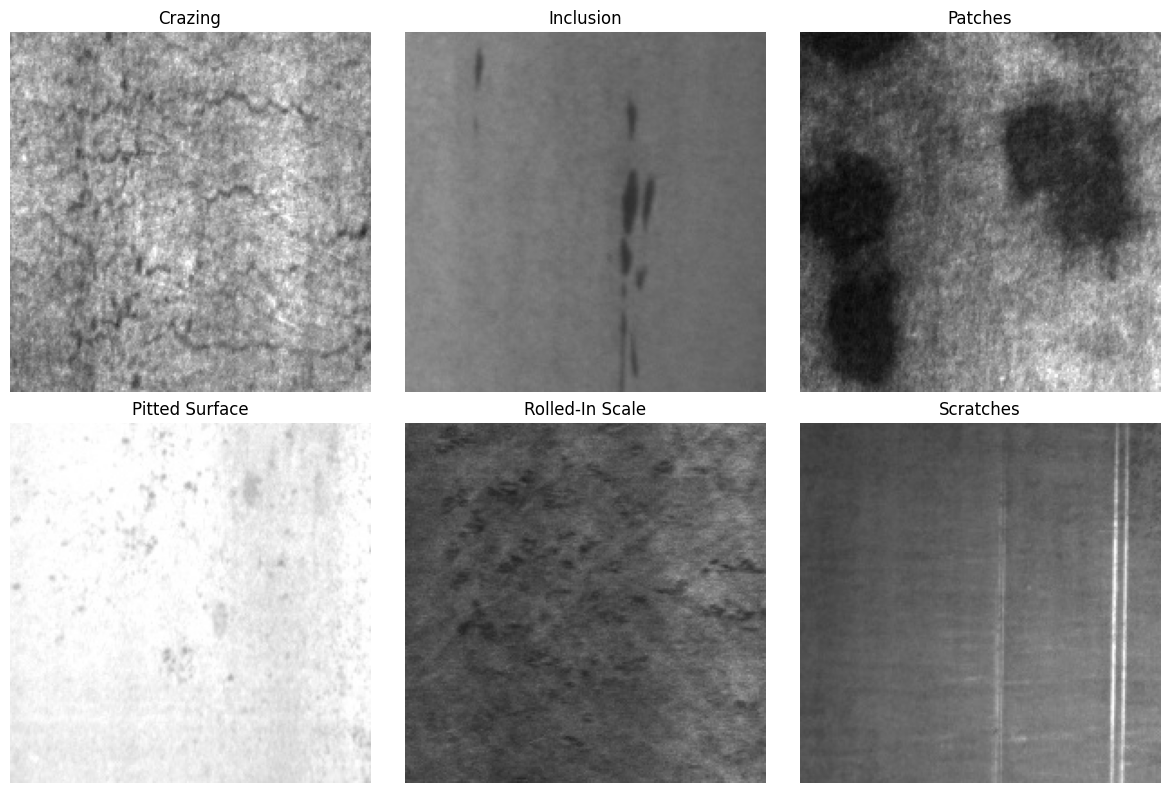

In [18]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_root = Path("data/raw/NEU-DET/train/images")
class_names = sorted(folder.name for folder in image_root.iterdir() if folder.is_dir())

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for axis, class_name in zip(axes, class_names):
    first_image_path = next((image_root / class_name).glob("*"))

    with Image.open(first_image_path) as image:
        axis.imshow(image)

    axis.set_title(class_name.replace("_", " ").title())
    axis.axis("off")

plt.tight_layout()
plt.show()

In [19]:
from PIL import Image, UnidentifiedImageError

dataset_root = Path("data/raw/NEU-DET")
corrupted_files = []

for image_path in dataset_root.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in {
        ".jpg", ".jpeg", ".png", ".bmp"
    }:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except (UnidentifiedImageError, OSError, ValueError) as error:
            corrupted_files.append({
                    "file": str(image_path),
                    "error": str(error),})

print("Corrupted images:", len(corrupted_files))
if corrupted_files:
    print(corrupted_files[:5])

Corrupted images: 0


In [20]:
from collections import defaultdict
import hashlib

dataset_root = Path("data/raw/NEU-DET")
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

hash_to_files = defaultdict(list)

for image_path in dataset_root.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in image_extensions:
        file_hash = hashlib.sha256(image_path.read_bytes()).hexdigest()
        hash_to_files[file_hash].append(str(image_path))

duplicate_groups = {
    file_hash: files
    for file_hash, files in hash_to_files.items()
    if len(files) > 1
}

print("Duplicate image groups:", len(duplicate_groups))

if duplicate_groups:
    for files in list(duplicate_groups.values())[:5]:
        print("\nDuplicate files:")
        for file in files:
            print(file)

Duplicate image groups: 1

Duplicate files:
data/raw/NEU-DET/train/images/patches/patches_101.jpg
data/raw/NEU-DET/train/images/patches/patches_105.jpg


In [21]:
from pathlib import Path
import pandas as pd

Path("data/interim").mkdir(parents=True, exist_ok=True)

duplicate_action = pd.DataFrame(
    [
        {
            "keep_file": "data/raw/NEU-DET/train/images/patches/patches_101.jpg",
            "exclude_file": "data/raw/NEU-DET/train/images/patches/patches_105.jpg",
            "reason": "Exact duplicate in original training data",
        }
    ]
)
duplicate_action.to_csv(
    "data/interim/excluded_duplicates.csv",
    index=False,
)
print(duplicate_action)

                                           keep_file  \
0  data/raw/NEU-DET/train/images/patches/patches_...   

                                        exclude_file  \
0  data/raw/NEU-DET/train/images/patches/patches_...   

                                      reason  
0  Exact duplicate in original training data  


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths
train_root = Path("data/raw/NEU-DET/train/images")
split_dir = Path("data/interim/splits")
split_dir.mkdir(parents=True, exist_ok=True)

# Build a table of every original training image
records = []

for class_folder in sorted(train_root.iterdir()):
    if class_folder.is_dir():
        for image_path in class_folder.glob("*"):
            if image_path.is_file():
                records.append(
                    {
                        "path": image_path.as_posix(),
                        "label": class_folder.name,
                    }
                )

train_df = pd.DataFrame(records)

# Remove the exact duplicate chosen earlier
excluded_file = "data/raw/NEU-DET/train/images/patches/patches_105.jpg"
train_df = train_df[train_df["path"] != excluded_file].reset_index(drop=True)

# Make reproducible 0.85 train / 0.15 validation split
train_split, validation_split = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"],
)
# Save splitted files
train_split.to_csv(split_dir / "train.csv", index=False)
validation_split.to_csv(split_dir / "validation.csv", index=False)
print("Train images:", len(train_split))
print("Validation images:", len(validation_split))
print("\nTrain class counts:")
print(train_split["label"].value_counts().sort_index())
print("\nValidation class counts:")
print(validation_split["label"].value_counts().sort_index())

Train images: 1223
Validation images: 216

Train class counts:
label
crazing            204
inclusion          204
patches            203
pitted_surface     204
rolled-in_scale    204
scratches          204
Name: count, dtype: int64

Validation class counts:
label
crazing            36
inclusion          36
patches            36
pitted_surface     36
rolled-in_scale    36
scratches          36
Name: count, dtype: int64


In [23]:
test_root = Path("data/raw/NEU-DET/validation/images")
split_dir = Path("data/interim/splits")

test_records = []

for class_folder in sorted(test_root.iterdir()):
    if class_folder.is_dir():
        for image_path in class_folder.glob("*"):
            if image_path.is_file():
                test_records.append(
                    {
                        "path": image_path.as_posix(),
                        "label": class_folder.name,
                    }
                )

test_df = pd.DataFrame(test_records)

test_df.to_csv(split_dir / "test.csv", index=False)

print("Test images:", len(test_df))
print("\nTest class counts:")
print(test_df["label"].value_counts().sort_index())

Test images: 360

Test class counts:
label
crazing            60
inclusion          60
patches            60
pitted_surface     60
rolled-in_scale    60
scratches          60
Name: count, dtype: int64


In [25]:
import json
report_dir = Path("reports/data_understanding")
report_dir.mkdir(parents=True, exist_ok=True)
all_splits = pd.concat(
    [
        train_split.assign(split="train"),
        validation_split.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)
class_distribution = (
    all_splits.groupby(["split", "label"])
    .size()
    .reset_index(name="image_count")
)
class_distribution.to_csv(
    report_dir / "class_distribution.csv",
    index=False,
)
summary = {
    "dataset_name": "NEU Surface Defect Database",
    "classes": sorted(test_df["label"].unique().tolist()),
    "original_training_images": 1440,
    "provided_test_images": 360,
    "excluded_exact_duplicates": 1,
    "excluded_file": "data/raw/NEU-DET/train/images/patches/patches_105.jpg",
    "final_split_sizes": {
        "train": len(train_split),
        "validation": len(validation_split),
        "test": len(test_df),
    },
    "random_seed": 42,
}
with open(report_dir / "dataset_summary.json", "w") as file:
    json.dump(summary, file, indent=2)
print(json.dumps(summary, indent=2))
print("\nSaved:")
print("reports/data_understanding/dataset_summary.json")
print("reports/data_understanding/class_distribution.csv")

{
  "dataset_name": "NEU Surface Defect Database",
  "classes": [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
  ],
  "original_training_images": 1440,
  "provided_test_images": 360,
  "excluded_exact_duplicates": 1,
  "excluded_file": "data/raw/NEU-DET/train/images/patches/patches_105.jpg",
  "final_split_sizes": {
    "train": 1223,
    "validation": 216,
    "test": 360
  },
  "random_seed": 42
}

Saved:
reports/data_understanding/dataset_summary.json
reports/data_understanding/class_distribution.csv


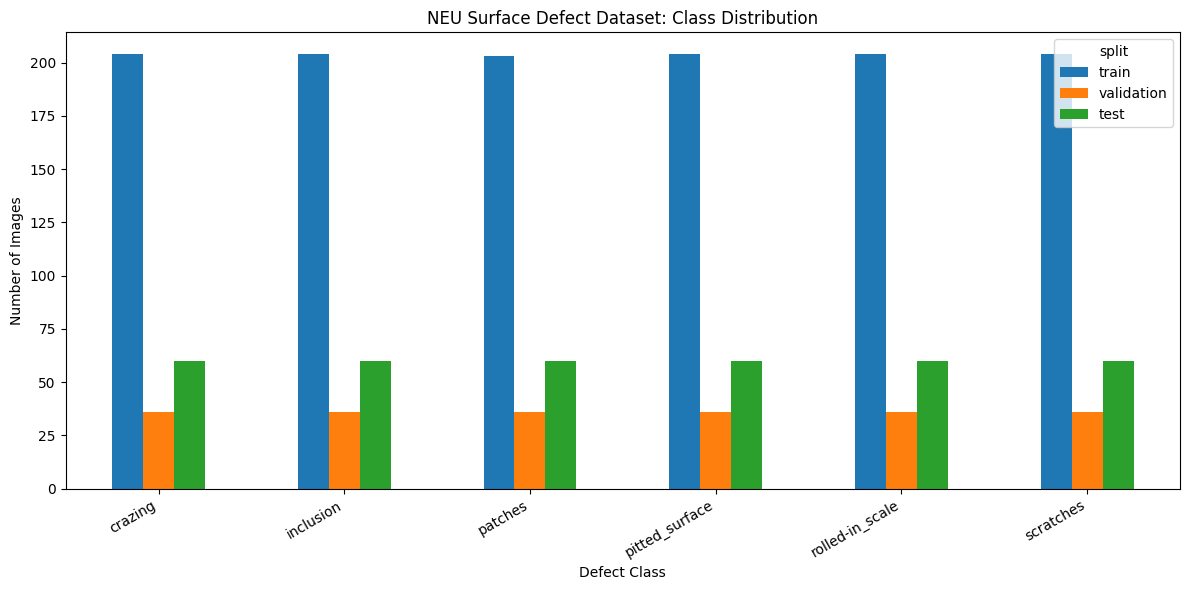

Saved chart to: reports/figures/class_distribution.png


In [26]:
figure_dir = Path("reports/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

distribution_df = pd.read_csv(
    "reports/data_understanding/class_distribution.csv"
)

plot_df = (
    distribution_df
    .pivot(index="label", columns="split", values="image_count")
    .reindex(columns=["train", "validation", "test"])
)

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("NEU Surface Defect Dataset: Class Distribution")
ax.set_xlabel("Defect Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = figure_dir / "class_distribution.png"
plt.savefig(output_path, dpi=160)
plt.show()

print(f"Saved chart to: {output_path}")

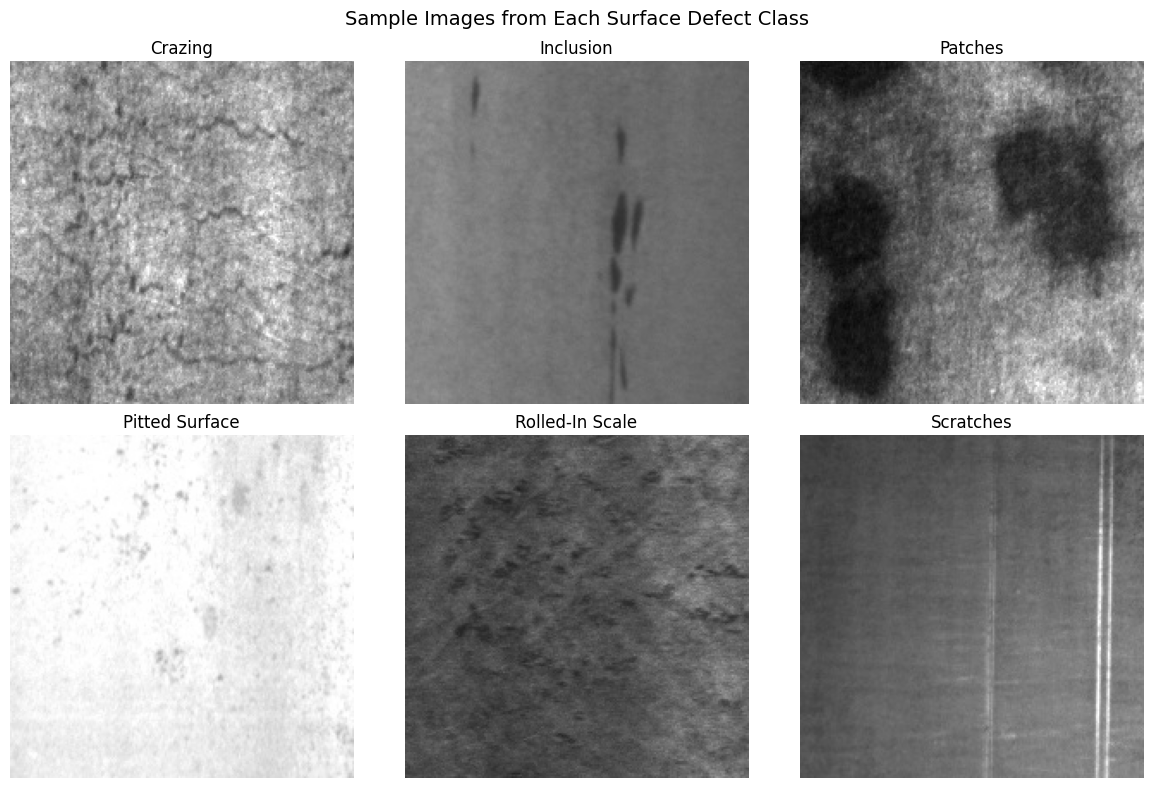

Saved chart to: reports/figures/sample_defect_images.png


In [27]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

figure_dir = Path("reports/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

train_root = Path("data/raw/NEU-DET/train/images")
class_names = sorted(
    folder.name for folder in train_root.iterdir()
    if folder.is_dir()
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for axis, class_name in zip(axes, class_names):
    image_path = next((train_root / class_name).glob("*"))

    with Image.open(image_path) as image:
        axis.imshow(image)

    axis.set_title(class_name.replace("_", " ").title())
    axis.axis("off")
plt.suptitle("Sample Images from Each Surface Defect Class", fontsize=14)
plt.tight_layout()
output_path = figure_dir / "sample_defect_images.png"
plt.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to: {output_path}")

In [28]:
split_dir = Path("data/interim/splits")
train_manifest = pd.read_csv(split_dir / "train.csv").assign(split="train")
validation_manifest = pd.read_csv(split_dir / "validation.csv").assign(split="validation")
test_manifest = pd.read_csv(split_dir / "test.csv").assign(split="test")

all_manifests = pd.concat(
    [train_manifest, validation_manifest, test_manifest],
    ignore_index=True,
)

hash_to_splits = defaultdict(list)
for row in all_manifests.itertuples(index=False):
    image_path = Path(row.path)
    image_hash = hashlib.sha256(image_path.read_bytes()).hexdigest()

    hash_to_splits[image_hash].append(
        {"path": row.path, "split": row.split, "label": row.label}
    )
leakage_groups = [
    files
    for files in hash_to_splits.values()
    if len({item["split"] for item in files}) > 1
]
print("Duplicate-content groups across final splits:", len(leakage_groups))
if leakage_groups:
    for group in leakage_groups[:5]:
        print("\nPotential leakage:")
        for item in group:
            print(item)

Duplicate-content groups across final splits: 0


In [29]:
import shutil
source_items = [
    Path("data/interim"),
    Path("reports"),
]
backup_root = Path("/content/drive/MyDrive/surface-scan-mlops/data_understanding")
backup_root.mkdir(parents=True, exist_ok=True)

for source in source_items:
    destination = backup_root / source.name

    if destination.exists():
        shutil.rmtree(destination)

    shutil.copytree(source, destination)
print("Backup completed:")
print(backup_root)

Backup completed:
/content/drive/MyDrive/surface-scan-mlops/data_understanding
